In [ ]:
import pysam
import pandas as pd
import pyBigWig
import numpy as np
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests as multi

def process_circle_matrix_mappability(matrix_file, bam_file, output_file,
                                   mappability_bw=None, map_window=30,
                                   use_chr_prefix=False, N_offset=1,
                                   lam=0.2, s0=10, m0=4, verbose=False):
    """
    Processes a circle matrix and extracts read counts from a BAM file,
    adjusting CJ imbalance by mappability and read quality.

    Parameters:
        matrix_file (str): CSV with circle regions
        bam_file (str): BAM file path
        output_file (str): CSV output path
        mappability_bw (str): BigWig file for per-base mappability (optional)
        map_window (int): Window size to average mappability
        use_chr_prefix (bool): Add 'chr' prefix to chromosome names
        N_offset (int): Offset for read counting around CJ
        lam, s0, m0 (float): weight parameters
        verbose (bool): print debug info
    """
    def safe_bw_values(bw, chrom, start, end, chrom_len):
        bw_chrom_prefix = any(c.startswith("chr") for c in bw.chroms())
        bw_chrom = chrom
        if bw_chrom_prefix and not chrom.startswith('chr'):
            bw_chrom = 'chr' + chrom
        if bw_chrom not in bw.chroms():
            return None
        start = max(0, start)
        end = min(end, chrom_len-1)
        if end <= start:
            return None
        return bw.values(bw_chrom, start, end, numpy=True)

    def extract_features(read, breakpoint_pos, window=20):
        features = {}
        features['MAPQ'] = read.mapping_quality
        try:
            features['NM'] = read.get_tag('NM')
        except KeyError:
            features['NM'] = 0
        softclip_len = 0
        if read.cigartuples:
            ref_pos = read.reference_start
            for op, length in read.cigartuples:
                if op == 4 and abs(ref_pos - breakpoint_pos) <= window:
                    softclip_len += length
                if op in (0,2,3):
                    ref_pos += length
        features['softclip'] = softclip_len
        features['MH'] = 0
        return features

    def compute_weight(f, lam=lam, s0=s0, m0=m0):
        w_mapq = 0 if f['MAPQ']==0 else min(1, f['MAPQ']/60)
        w_nm = np.exp(-lam * f['NM'])
        w_sc = 1 / (1 + f['softclip']/s0)
        w_mh = 1 / (1 + f['MH']/m0)
        return w_mapq * w_nm * w_sc * w_mh

    bam = pysam.AlignmentFile(bam_file, "rb")
    bw = None
    chrom_dict = None
    if mappability_bw:
        bw = pyBigWig.open(mappability_bw)
        chrom_dict = bw.chroms()
        if not use_chr_prefix:
            chrom_dict = {k.replace("chr",""): v for k,v in chrom_dict.items()}

    df = pd.read_csv(matrix_file)
    results = []

    for idx, row in df.iterrows():
        circle = row['Circles']
        try:
            chrom, coords = circle.split(":")
            start, end = map(int, coords.split("-"))
            if start > end:
                start, end = end, start
        except ValueError:
            continue
        if use_chr_prefix and not chrom.startswith('chr'):
            chrom = 'chr'+chrom
        try:
            tools_detected = row.iloc[1:].sum()

            # Fetch reads
            CJ1_reads = list(bam.fetch(chrom, start-N_offset, start+N_offset))
            CJ2_reads = list(bam.fetch(chrom, end-N_offset, end+N_offset))

            CJ1_count = len(CJ1_reads)
            CJ2_count = len(CJ2_reads)
            CJ_reads = CJ1_count + CJ2_count
            diff_CJ = abs(CJ1_count - CJ2_count)

            ratio_CJ1 = CJ1_count / CJ_reads if CJ_reads > 0 else 0
            ratio_CJ2 = CJ2_count / CJ_reads if CJ_reads > 0 else 0
            max_CJ, min_CJ = max(ratio_CJ1, ratio_CJ2), min(ratio_CJ1, ratio_CJ2)
            rel_diff_CJ = max_CJ - min_CJ

            CJ_unique_reads = len(set(r.query_name for r in CJ1_reads+CJ2_reads))
            total_reads = len({r.query_name for r in bam.fetch(chrom, start-N_offset, end+N_offset)})
            ratio = CJ_unique_reads / total_reads if total_reads>0 else 0

            # Weighted counts
            features_CJ1 = [extract_features(r, start) for r in CJ1_reads]
            features_CJ2 = [extract_features(r, end) for r in CJ2_reads]
            weights_CJ1 = [compute_weight(f) for f in features_CJ1]
            weights_CJ2 = [compute_weight(f) for f in features_CJ2]

            kL_w = sum(weights_CJ1)
            kR_w = sum(weights_CJ2)
            n_w = kL_w + kR_w
            all_weights = weights_CJ1 + weights_CJ2
            diff_weighted = abs(kL_w - kR_w)
            ratio_wL = kL_w / n_w if n_w > 0 else 0
            ratio_wR = kR_w / n_w if n_w > 0 else 0
            max_w, min_w = max(ratio_wL, ratio_wR), min(ratio_wL, ratio_wR)
            rel_diff_weighted = max_w - min_w       
            
            neff = (sum(all_weights)**2)/sum([w**2 for w in all_weights]) if sum([w**2 for w in all_weights])>0 else 0

            # Mappability
            p_L = 0.5
            M_L, M_R = None, None
            if bw and chrom in chrom_dict:
                chrom_len = chrom_dict[chrom]
                vals_L = safe_bw_values(bw, chrom, start, start+map_window, chrom_len)
                vals_R = safe_bw_values(bw, chrom, end-map_window, end, chrom_len)
                if vals_L is not None and vals_R is not None:
                    M_L = float(pd.Series(vals_L).mean(skipna=True))
                    M_R = float(pd.Series(vals_R).mean(skipna=True))
                    if (M_L + M_R) > 0:
                        p_L = M_L / (M_L + M_R)

            # Z and p-value
            Z = (kL_w - n_w*p_L)/np.sqrt(neff*p_L*(1-p_L)) if neff>0 else 0
            p_value = 2*(1-norm.cdf(abs(Z))) if neff>0 else 1

            results.append([
                circle, end-start+1, tools_detected,
                CJ1_count, CJ2_count, CJ_reads, diff_CJ, 
                total_reads, ratio,
                ratio_CJ1, ratio_CJ2, rel_diff_CJ,
                kL_w, kR_w, n_w, diff_weighted, 
                ratio_wL, ratio_wR, rel_diff_weighted,
                Z, p_value,
                M_L, M_R, p_L
            ])
        except ValueError as e:
            # Handle the error if there's an invalid chromosome or other issue
            print(f"Skipping invalid chromosome: {chrom} or region {circle}. Error: {e}")
            continue
        
    bam.close()
    if bw:
        bw.close()

    # Build DataFrame with original + weighted columns
    columns=[
        "Circle","Length","Tools",
        "CJ1 Reads","CJ2 Reads","CJ Reads","diff CJ",
        "Total Reads","Ratio",
        "CJ1 Ratio","CJ2 Ratio","rel diff CJ",
        "kL_weighted","kR_weighted","n_weighted","diff_weighted",
        "KL_ratio","KR_ratio","rel diff weighted",
        "Z_score","p diff CJ",
        "Mappability L","Mappability R","p_L"
    ]
    output_df = pd.DataFrame(results, columns=columns)

    # FDR correction
    adjusted_p = multi(output_df['p diff CJ'].values, method='fdr_bh')[1]
    output_df['p diff CJ*'] = adjusted_p

    output_df.to_csv(output_file, index=False)


In [190]:
eccDNA_matrix = 'results/eccDNA/insilico/filter/truepositives/truepositives_matrix.csv'
eccDNA_bam = 'output/eccDNA/insilico/bam/sorted_unknown_DNA_cov30.bam'
eccDNA_reads = 'CJ/truepositives_reads.csv'
process_circle_matrix_mappability(eccDNA_matrix, eccDNA_bam, eccDNA_reads, N_offset=20, mappability_bw='/home/neuroim/Downloads/k50.Umap.MultiTrackMappability.bw')

In [191]:
import os
import pandas as pd
import pysam
import pyBigWig
from scipy.stats import binom, kruskal, median_abs_deviation
from statsmodels.stats.multitest import multipletests as multi
from matplotlib import pyplot as plt
import seaborn as sns
import scikit_posthocs as sp
import numpy as np
import matplotlib.gridspec as gridspec

def circle_diff(matrix_dir, matrix_reads, tools, output_dir, group):
    """
    Analyzes circle detection differences across tools based on read counts and statistics.

    Parameters:
        matrix_dir (str): Path to the CSV file containing circle presence matrix.
        matrix_reads (str): Path to the CSV file containing reads and differential CJ statistics.
        tools (list of str): List of tool names to analyze.
        output_dir (str): Directory to save summary CSV and plots.
        group (str): Group identifier used for naming output files.

    Returns:
        None
    """
    # Define file paths
    matrix_path = os.path.join(matrix_dir)
    matrix_with_reads_path = os.path.join(matrix_reads)

    # Load data
    matrix_df = pd.read_csv(matrix_path)
    reads_df = pd.read_csv(matrix_with_reads_path)

    # Merge on circle ID
    merged_df = pd.merge(matrix_df, reads_df[['Circle', 'kL_weighted', 'kR_weighted', 'n_weighted', 'rel diff weighted', 'p diff CJ', 'p diff CJ*']], left_on='Circles', right_on='Circle', how='inner')

    n_threshold = 9
    alpha = 0.05

    summary_stats = []  # List to store summary statistics
    significance_stats = []  # List to store significance statistics

    for tool in tools:
        tool_data = merged_df[merged_df[tool] == 1]
        
        filter_data_max = tool_data[tool_data['n_weighted'] >= n_threshold]
        filter_data_min = tool_data[tool_data['n_weighted'] < n_threshold]
 
        # Collecting the statistics
        summary_stats.append({
            'Tool': tool,
            'Percentage CJ Reads >= 9': len(filter_data_max) / len(tool_data),
            'Median ACJ (>=9)': filter_data_max['rel diff weighted'].median(),
            'Mean ACJ (>=9)': filter_data_max['rel diff weighted'].mean(),
            'Median ACJ (<9)': filter_data_min['rel diff weighted'].median(),
            'Mean ACJ (<9)': filter_data_min['rel diff weighted'].mean(),
            'Ratio p diff CJ < alpha (>=9)': len(filter_data_max[filter_data_max['p diff CJ'] < alpha]) / len(filter_data_max),
            'Ratio p diff CJ* < alpha (>=9)': len(filter_data_max[filter_data_max['p diff CJ*'] < alpha]) / len(filter_data_max),
            'Ratio p diff CJ < alpha (<9)': len(filter_data_min[filter_data_min['p diff CJ'] < alpha]) / len(filter_data_min),
            'Ratio p diff CJ* < alpha (<9)': len(filter_data_min[filter_data_min['p diff CJ*'] < alpha]) / len(filter_data_min),
        })

        # if tool == "Simulated":
        #     circles_cabrones = filter_data_max[filter_data_max['p diff CJ*'] < alpha]
        #     display(circles_cabrones)

    # Save summary statistics as CSV
    summary_df = pd.DataFrame(summary_stats)
    
    # Define output path
    output_csv_path = os.path.join(output_dir, 'statistics_summary.csv')
    os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)

    # Save the summary DataFrame to CSV
    summary_df.to_csv(output_csv_path)

    # Prepare data for plotting
    plot_data = []
    for tool in tools:
        tool_data = merged_df[merged_df[tool] == 1]
        for _, row in tool_data.iterrows():
            plot_data.append({
                'Tool': tool,
                'diff CJ': row['rel diff weighted']
            })

    # Define color palette
    palette = {
        'Simulated': '#b3b3b3',
        'unfilter': '#d46014',
        'filter-split': '#ddcd3d',
        'filter-duplicates': '#064b76ff',
        'filter': '#63bdf6ff'
    }

    # Create DataFrame for plotting
    plot_df = pd.DataFrame(plot_data)
    plot_df
    # Plot
    plt.figure(figsize=(8.5, 4))
    ax = sns.boxplot(x="Tool", y="diff CJ", data=plot_df, palette=palette)

    # Axis labels and ticks
    plt.xlabel('')
    plt.ylabel('ΔCJ', fontsize=16)
    xtick_labels = tools
    plt.xticks(ticks=range(len(xtick_labels)), labels=xtick_labels, fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(axis="y", linestyle='--', linewidth=0.5, alpha=0.7)
    sns.despine()
    plt.tight_layout()

    # Add counts on top of each box
    group_counts = plot_df.groupby('Tool').size()
    global_ymax = plot_df['diff CJ'].max()

    for i, tool in enumerate(tools):
        count = group_counts.get(tool, 0)
        if count > 0:
            y_text = 1.05
            ax.text(i, y_text, str(count), ha='center', va='bottom', fontsize=12)


    # Save the plot
    save_path = os.path.join(output_dir, f'{group}_diff_cj_plot.png')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    # Group data by tool for Kruskal-Wallis test
    grouped = [group["diff CJ"].values for _, group in plot_df.groupby("Tool") if not group.empty]

    # Perform Kruskal-Wallis test
    if len(grouped) > 1:
        stat, p_val = kruskal(*grouped)
        kruskal_results = [{
            'Test': 'Kruskal-Wallis (across Tools)',
            'H-statistic': stat,
            'p-value': p_val
        }]
        print(f"Kruskal-Wallis test across: H = {stat:.4f}, p = {p_val:.4e}")
    else:
        print("Not enough groups to perform Kruskal-Wallis test.")

/tmp/ipykernel_2202695/1201872296.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="Tool", y="diff CJ", data=plot_df, palette=palette)


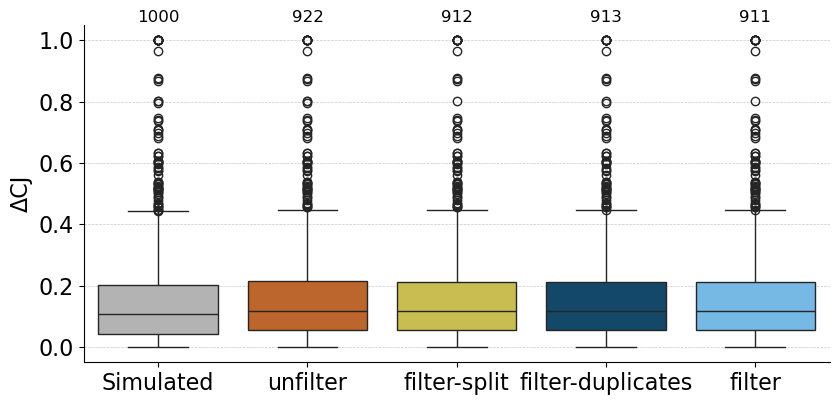

Kruskal-Wallis test across: H = 9.8079, p = 4.3791e-02


In [192]:
eccDNA_output = 'CJ/'
filtering = ["Simulated", "unfilter" ,"filter-split", "filter-duplicates", "filter"]
circle_diff(eccDNA_matrix, eccDNA_reads, filtering, eccDNA_output, group='truepositives')

In [193]:
eccDNA_matrix = 'results/eccDNA/insilico/filter/falsepositives/falsepositives_matrix.csv'
eccDNA_bam = 'output/eccDNA/insilico/bam/sorted_unknown_DNA_cov30.bam'
eccDNA_reads = 'CJ/falsepositives_reads.csv'
process_circle_matrix_mappability(eccDNA_matrix, eccDNA_bam, eccDNA_reads, N_offset=20, mappability_bw='/home/neuroim/Downloads/k50.Umap.MultiTrackMappability.bw')

/tmp/ipykernel_2202695/1201872296.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="Tool", y="diff CJ", data=plot_df, palette=palette)


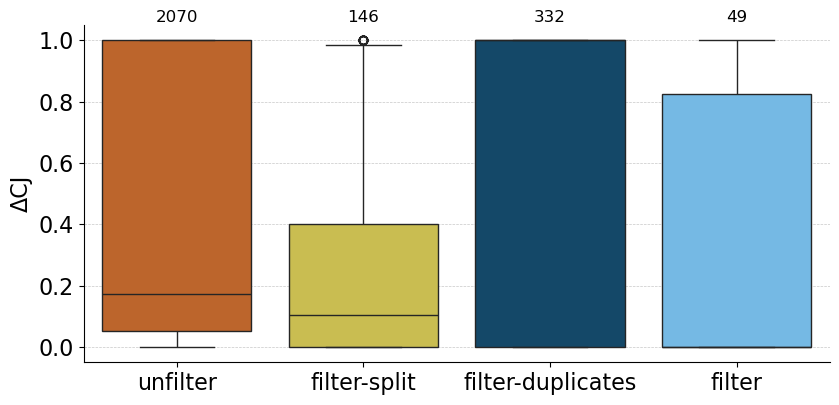

Kruskal-Wallis test across: H = 57.4535, p = 2.0564e-12


In [194]:
filtering = ["unfilter" ,"filter-split", "filter-duplicates", "filter"]
circle_diff(eccDNA_matrix, eccDNA_reads, filtering, eccDNA_output, group='falsepositives')

In [195]:
circRNA_matrix = 'results/circRNA/insilico/filter/truepositives/truepositives_matrix.csv'
circRNA_bam = 'output/circRNA/insilico/bam/circRNA_cov30.sorted.bam'
circRNA_reads = 'CJ/circRNA/truepositives_reads.csv'
process_circle_matrix_mappability(circRNA_matrix, circRNA_bam, circRNA_reads, N_offset=20, mappability_bw='/home/neuroim/Downloads/k50.Umap.MultiTrackMappability.bw', use_chr_prefix=True)

/tmp/ipykernel_2202695/1201872296.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="Tool", y="diff CJ", data=plot_df, palette=palette)


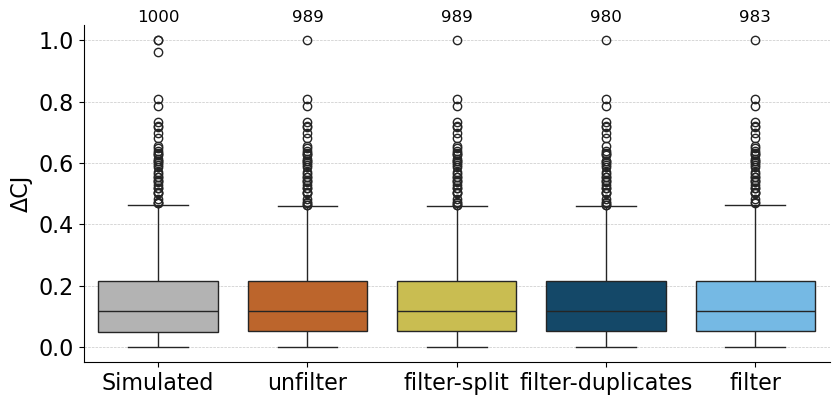

Kruskal-Wallis test across: H = 0.0518, p = 9.9967e-01


In [196]:
circRNA_output = 'CJ/circRNA'
filtering = ["Simulated", "unfilter" ,"filter-split", "filter-duplicates", "filter"]
circle_diff(circRNA_matrix, circRNA_reads, filtering, circRNA_output, group='truepositives')

In [197]:
circRNA_matrix = 'results/circRNA/insilico/filter/falsepositives/falsepositives_matrix.csv'
process_circle_matrix_mappability(circRNA_matrix, circRNA_bam, circRNA_reads, N_offset=20, mappability_bw='/home/neuroim/Downloads/k50.Umap.MultiTrackMappability.bw', use_chr_prefix=True)

/tmp/ipykernel_2202695/1201872296.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="Tool", y="diff CJ", data=plot_df, palette=palette)


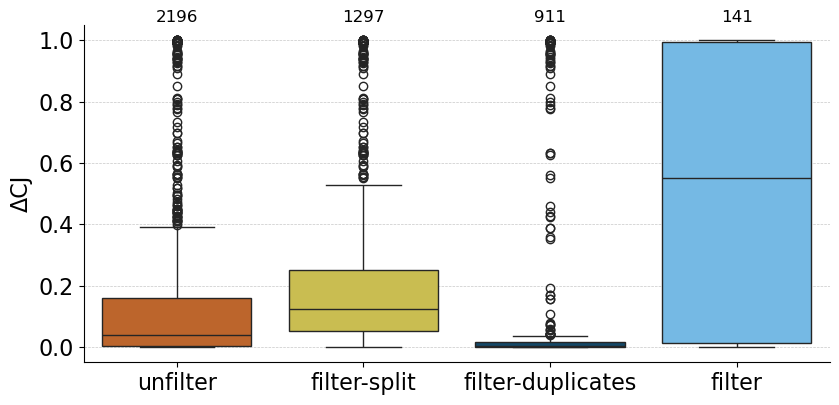

Kruskal-Wallis test across: H = 908.9221, p = 1.0274e-196


In [198]:
circRNA_output = 'CJ/circRNA'
filtering = ["unfilter" ,"filter-split", "filter-duplicates", "filter"]
circle_diff(circRNA_matrix, circRNA_reads, filtering, circRNA_output, group='falsepositives')

## Biological

In [206]:
filtering_methods = ["unfilter" ,"filter-split", "filter-duplicates", "filter"]
for filtering in filtering_methods:
    process_circle_matrix_mappability(
        f"results/eccDNA/real/{filtering}/Circle-Seq/matrix.csv",
        f"output/eccDNA/real/Circle-Seq/bwa/CS_sorted_unknown_circle.bam",
        f"CJ/eccDNA/real/{filtering}/Circle-Seq/matrix_with_reads.csv",
        N_offset=20, 
        verbose=False,
        mappability_bw='/home/neuroim/Downloads/k50.Umap.MultiTrackMappability.bw'
        )

Skipping invalid chromosome: M or region M:342-1130. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:394-2802. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:520-564. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:525-14363. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:777-904. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:995-5131. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:1243-3798. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:1250-15729. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:1364-3320. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:1461-3263. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:1691-5122. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:803-1939. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:1901

In [209]:
for filtering in filtering_methods:
    process_circle_matrix_mappability(
        f"results/eccDNA/real/{filtering}/ATAC-seq/matrix.csv",
        f"output/eccDNA/real/ATAC-seq/bwa/AS_sorted_unknown_circle.bam",
        f"CJ/eccDNA/real/{filtering}/ATAC-seq/matrix_with_reads.csv",
        N_offset=20, 
        verbose=False,
        mappability_bw='/home/neuroim/Downloads/k50.Umap.MultiTrackMappability.bw',
        use_chr_prefix=True,
        )

Skipping invalid chromosome: chrMT or region MT:0-16299. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrMT or region MT:652-8747. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrMT or region MT:11467-11796. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrUn_JH584304 or region Un_JH584304:15-114452. Error: start out of range (-5)
Skipping invalid chromosome: chrMT or region MT:0-16299. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrUn_JH584304 or region Un_JH584304:15-114452. Error: start out of range (-5)
Skipping invalid chromosome: chrMT or region MT:0-16299. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrUn_JH584304 or region Un_JH584304:15-114452. Error: start out of range (-5)
Skipping invalid chromosome: chrMT or region MT:0-16299. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrUn_JH584304 or region Un_JH584304:15-114452. Error: start out of range (-5)


In [211]:
for filtering in filtering_methods:
    process_circle_matrix_mappability(
        f"results/circRNA/real/{filtering}/CNT/matrix.csv",
        f"output/circRNA/real/star/CNT.Aligned.sorted.out.bam",
        f"CJ/circRNA/real/{filtering}/CNT/matrix_with_reads.csv",
        use_chr_prefix=True,
        N_offset=20, 
        mappability_bw='/home/neuroim/Downloads/k50.Umap.MultiTrackMappability.bw',
        verbose=False
    )

Skipping invalid chromosome: chrM or region M:0-16569. Error: start out of range (-20)
Skipping invalid chromosome: chrUn_GL000216v2 or region Un_GL000216v2:12-5381. Error: start out of range (-8)
Skipping invalid chromosome: chrUn_KI270333v1 or region Un_KI270333v1:8-1522. Error: start out of range (-12)
Skipping invalid chromosome: chrUn_KI270333v1 or region Un_KI270333v1:9-133. Error: start out of range (-11)
Skipping invalid chromosome: chrUn_KI270333v1 or region Un_KI270333v1:12-943. Error: start out of range (-8)
Skipping invalid chromosome: chrM or region M:0-16569. Error: start out of range (-20)
Skipping invalid chromosome: chrUn_KI270333v1 or region Un_KI270333v1:8-1522. Error: start out of range (-12)
Skipping invalid chromosome: chrM or region M:0-16569. Error: start out of range (-20)
Skipping invalid chromosome: chrM or region M:0-16569. Error: start out of range (-20)


In [3]:
filtering_methods = ["unfilter" ,"filter-split", "filter-duplicates", "filter"]
for filtering in filtering_methods:
    process_circle_matrix_mappability(
        f"results/circRNA/real/{filtering}/RNASE/matrix.csv",
        f"output/circRNA/real/star/RNASE.Aligned.sorted.out.bam",
        f"CJ/circRNA/real/{filtering}/RNASE/matrix_with_reads.csv",
        use_chr_prefix=True,
        N_offset=20, 
        mappability_bw='/home/neuroim/Downloads/k50.Umap.MultiTrackMappability.bw',
        verbose=False
    )

Skipping invalid chromosome: chrM or region M:0-16569. Error: start out of range (-20)
Skipping invalid chromosome: chrM or region M:0-16569. Error: start out of range (-20)
Skipping invalid chromosome: chrM or region M:0-16569. Error: start out of range (-20)


In [3]:
def circle_diff_real(matrix_dir, tools, filtering_methods, data, n_threshold=9, alpha=0.05):
    """
    Perform comparative analysis of detected circular DNA/RNA across tools and filtering strategies.

    This function loads detection matrices and associated CJ Read counts for various combinations of 
    tools and filtering methods, computes summary statistics, categorizes circles by CJ Read threshold, 
    generates comparative boxplots, and performs non-parametric statistical tests (Kruskal-Wallis and Dunn's test) 
    to evaluate differences in ΔCJ (difference in circular junction reads) distributions.

    Summary statistics include the number and percentage of high-confidence circles (above threshold), 
    median/mean ΔCJ values, and the proportion of statistically significant changes.

    Parameters:
        matrix_dir (str): Path to the base directory containing 'matrix.csv' and 'matrix_with_reads.csv' files 
                        for each filtering method and dataset.
        tools (list): List of tool names to include in the analysis (e.g., ['Circle-Map', 'CIRCexplorer2']).
        filtering_methods (list): List of filtering method names (e.g., ['filter', 'unfilter']).
        data (str): Name of the dataset (used in file paths and output plot titles).
        n_threshold (int, optional): Threshold for CJ Read count to define high-confidence circles (default is 9).
        alpha (float, optional): Significance level for p-value thresholds (default is 0.05).

    Returns:
        None

    Outputs:
        CSV file with summary statistics for each tool and filtering method.
        PNG boxplot visualizing ΔCJ distributions across tools and filters.
        Excel file containing Kruskal-Wallis and Dunn's test results for ΔCJ comparisons.
    """

    plot_data = []
    kruskal_results = []
    dunn_results = []
    summary_stats = []
    significance_stats = []

    def load_matrix_data(filtering_method, tool):
        matrix_path = os.path.join(matrix_dir, filtering_method, data, 'matrix.csv')
        matrix_with_reads_path = os.path.join(matrix_dir, filtering_method, data, 'matrix_with_reads.csv')

        if not os.path.exists(matrix_path) or not os.path.exists(matrix_with_reads_path):
            print(f"File(s) missing for {filtering_method}: {matrix_path} or {matrix_with_reads_path}")
            return

        matrix_data = pd.read_csv(matrix_path)
        matrix_with_reads = pd.read_csv(matrix_with_reads_path)

        merged_data = pd.merge(
            matrix_data,
            matrix_with_reads[['Circle', 'kL_weighted', 'kR_weighted', 'n_weighted', 'rel diff weighted', 'p diff CJ', 'p diff CJ*']],
            left_on='Circles',
            right_on='Circle',
            how='inner'
        )

        tool_data = merged_data[merged_data[tool] == 1]
        filter_data_max = tool_data[tool_data['n_weighted'] >= n_threshold]
        filter_data_min = tool_data[tool_data['n_weighted'] < n_threshold]

        percent_max = len(filter_data_max) / len(tool_data) if len(tool_data) > 0 else np.nan

        # Collecting the statistics
        summary_stats.append({
            'Tool': tool,
            'Percentage CJ Reads >= 9': len(filter_data_max) / len(tool_data),
            'Median ACJ (>=9)': filter_data_max['rel diff weighted'].median(),
            'Mean ACJ (>=9)': filter_data_max['rel diff weighted'].mean(),
            'Median ACJ (<9)': filter_data_min['rel diff weighted'].median(),
            'Mean ACJ (<9)': filter_data_min['rel diff weighted'].mean(),
            'Ratio p diff CJ < alpha (>=9)': len(filter_data_max[filter_data_max['p diff CJ'] < alpha]) / len(filter_data_max),
            'Ratio p diff CJ* < alpha (>=9)': len(filter_data_max[filter_data_max['p diff CJ*'] < alpha]) / len(filter_data_max),
            'Ratio p diff CJ < alpha (<9)': len(filter_data_min[filter_data_min['p diff CJ'] < alpha]) / len(filter_data_min),
            'Ratio p diff CJ* < alpha (<9)': len(filter_data_min[filter_data_min['p diff CJ*'] < alpha]) / len(filter_data_min),
        })

        for _, row in filter_data_max.iterrows():
            plot_data.append({
                'Tool': tool,
                'Filtering': filtering_method,
                'Circle': row['Circles'],
                'diff CJ': row['rel diff weighted']
            })

    for tool in tools:
        for filtering_method in filtering_methods:
            load_matrix_data(filtering_method, tool)

    # Save summary stats once after all iterations
    summary_save_path = os.path.join(matrix_dir, data, 'statistics_summary.csv')
    os.makedirs(os.path.dirname(summary_save_path), exist_ok=True)
    pd.DataFrame(summary_stats).to_csv(summary_save_path, index=False)

    plot_df = pd.DataFrame(plot_data)

    if not plot_df.empty:
        palette = {
            'unfilter': '#d46014',
            'filter-split': '#ddcd3d',
            'filter-duplicates': '#064b76ff',
            'filter': '#63bdf6ff'
        }

        plt.figure(figsize=(10, 4))
        ax = sns.boxplot(x="Tool", y="diff CJ", hue="Filtering", data=plot_df, palette=palette)
        plt.xlabel('')
        plt.ylabel('ΔCJ', fontsize=16)
        if data == 'Circle-Seq' or data == 'ATAC-seq':
            plt.xticks(ticks=range(len(tools)), labels=['CIRCexplorer2', 'Circle-Map', 'Circle_finder', 'ecc_finder\nbwa', 'ecc_finder\nminimap2'], fontsize=16)
        else:
            plt.xticks(ticks=range(len(tools)), labels=tools, fontsize=16)
        plt.yticks(fontsize=16)
        ax.legend_.remove()
        plt.grid(axis="y", linestyle='--', linewidth=0.5, alpha=0.7)
        sns.despine()
        plt.tight_layout()

        group_counts = plot_df.groupby(['Tool', 'Filtering']).size().reset_index(name='count')
        for i, (tool, filtering) in enumerate(group_counts[['Tool', 'Filtering']].values):
            count = group_counts.loc[
                (group_counts['Tool'] == tool) & (group_counts['Filtering'] == filtering),
                'count'
            ].values[0]
            tool_idx = tools.index(tool)
            filtering_idx = list(palette.keys()).index(filtering)
            total_hue = len(palette)
            spacing_factor = 0.85
            x_position = tool_idx + ((filtering_idx - total_hue / 2) * spacing_factor / total_hue) + 0.1
            ax.text(x_position, 1.02, f'{count}', ha='center', va='bottom', fontsize=14, rotation=45)

        save_path = os.path.join(matrix_dir, data, 'diff CJ.png')
        os.makedirs(os.path.join(matrix_dir, data), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

        for filtering_method in filtering_methods:
            df_sub = plot_df[plot_df['Filtering'] == filtering_method]
            if not df_sub.empty:
                groups = [df_sub[df_sub['Tool'] == tool]['diff CJ'].values for tool in tools]
                if len(groups) > 1:
                    stat, p_val = kruskal(*groups)
                    kruskal_results.append({
                        'Filtering Method': filtering_method,
                        'Test': 'Kruskal-Wallis (Tools)',
                        'H-statistic': stat,
                        'p-value': p_val
                    })
                    print(f"Kruskal-Wallis test for filtering method {filtering_method}: H = {stat:.4f}, p = {p_val:.4f}")

                    dunn_result = sp.posthoc_dunn(df_sub, val_col='diff CJ', group_col='Tool', p_adjust='bonferroni')
                    dunn_results.append({
                        'Filtering Method': filtering_method,
                        'Test': 'Dunn\'s test (Tools)',
                        'results': dunn_result
                    })
                    print(f"  Dunn's test for {filtering_method}: \n{dunn_result}")


        output_dir = os.path.join(matrix_dir, data)
        os.makedirs(output_dir, exist_ok=True)

        output_excel_path = os.path.join(output_dir, 'statistical_results.xlsx')
        with pd.ExcelWriter(output_excel_path) as writer:
            # Save Kruskal-Wallis results
            pd.DataFrame(kruskal_results).to_excel(writer, sheet_name='Kruskal-Wallis', index=False)
            
            # Save Dunn's test results
            for result in dunn_results:
                sheet_name = f"Dunn_{result['Filtering Method']}"
                result['results'].to_excel(writer, sheet_name=sheet_name[:31], index=True)  # Excel sheet name limit = 31 chars

    else:
        print("Plotting skipped due to empty DataFrame.")   


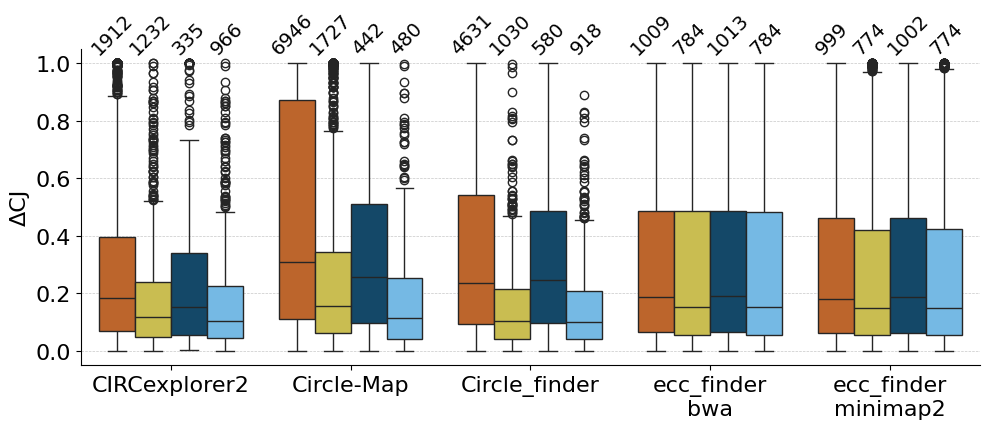

Kruskal-Wallis test for filtering method unfilter: H = 408.3170, p = 0.0000
  Dunn's test for unfilter: 
                     CIRCexplorer2    Circle-Map  Circle_finder  \
CIRCexplorer2         1.000000e+00  5.751427e-53   1.507603e-28   
Circle-Map            5.751427e-53  1.000000e+00   9.273484e-11   
Circle_finder         1.507603e-28  9.273484e-11   1.000000e+00   
ecc_finder-bwa        3.300504e-28  1.000000e+00   2.412982e-05   
ecc_finder-minimap2   6.779974e-32  1.000000e+00   5.060295e-07   

                     ecc_finder-bwa  ecc_finder-minimap2  
CIRCexplorer2          3.300504e-28         6.779974e-32  
Circle-Map             1.000000e+00         1.000000e+00  
Circle_finder          2.412982e-05         5.060295e-07  
ecc_finder-bwa         1.000000e+00         1.000000e+00  
ecc_finder-minimap2    1.000000e+00         1.000000e+00  
Kruskal-Wallis test for filtering method filter-split: H = 130.2689, p = 0.0000
  Dunn's test for filter-split: 
                     CIRC

In [5]:
import os
import pandas as pd
import pysam
from scipy.stats import binom, kruskal, median_abs_deviation
from statsmodels.stats.multitest import multipletests as multi
from matplotlib import pyplot as plt
import seaborn as sns
import scikit_posthocs as sp
import numpy as np
import matplotlib.gridspec as gridspec

eccDNA_matrix = "CJ/eccDNA/real"
filtering_methods = ["unfilter", "filter-split", "filter-duplicates", "filter"]
data = 'Circle-Seq'
eccDNA_tools = ["Circle-Map", "CIRCexplorer2", "Circle_finder", "ecc_finder-bwa", "ecc_finder-minimap2"]    

circle_diff_real(eccDNA_matrix, eccDNA_tools, filtering_methods, data)

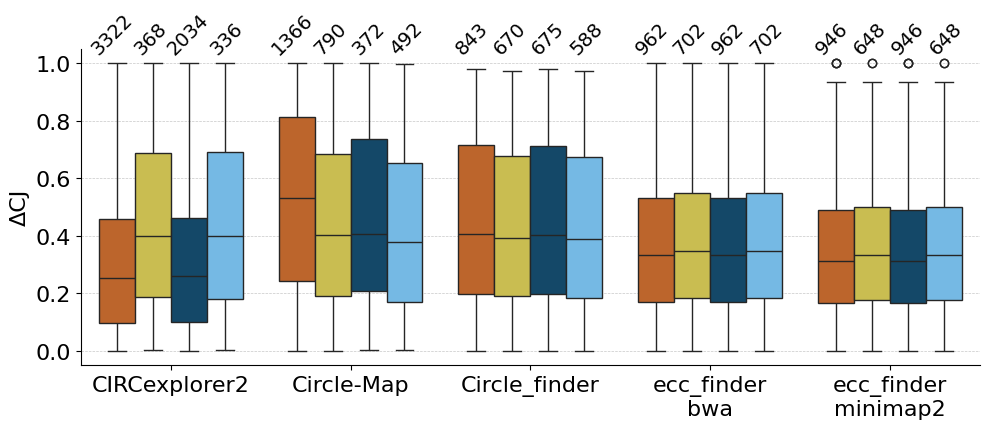

Kruskal-Wallis test for filtering method unfilter: H = 592.2376, p = 0.0000
  Dunn's test for unfilter: 
                     CIRCexplorer2     Circle-Map  Circle_finder  \
CIRCexplorer2         1.000000e+00  6.467234e-113   1.238304e-05   
Circle-Map           6.467234e-113   1.000000e+00   6.198168e-40   
Circle_finder         1.238304e-05   6.198168e-40   1.000000e+00   
ecc_finder-bwa        3.786566e-34   1.249237e-07   6.396991e-10   
ecc_finder-minimap2   1.807861e-42   8.982660e-04   3.785187e-14   

                     ecc_finder-bwa  ecc_finder-minimap2  
CIRCexplorer2          3.786566e-34         1.807861e-42  
Circle-Map             1.249237e-07         8.982660e-04  
Circle_finder          6.396991e-10         3.785187e-14  
ecc_finder-bwa         1.000000e+00         1.000000e+00  
ecc_finder-minimap2    1.000000e+00         1.000000e+00  
Kruskal-Wallis test for filtering method filter-split: H = 64.5760, p = 0.0000
  Dunn's test for filter-split: 
                    

In [6]:
eccDNA_matrix = "CJ/eccDNA/real"
filtering_methods = ["unfilter", "filter-split", "filter-duplicates", "filter"]
data = 'ATAC-seq'
eccDNA_tools = ["Circle-Map", "CIRCexplorer2", "Circle_finder", "ecc_finder-bwa", "ecc_finder-minimap2"]    

circle_diff_real(eccDNA_matrix, eccDNA_tools, filtering_methods, data)

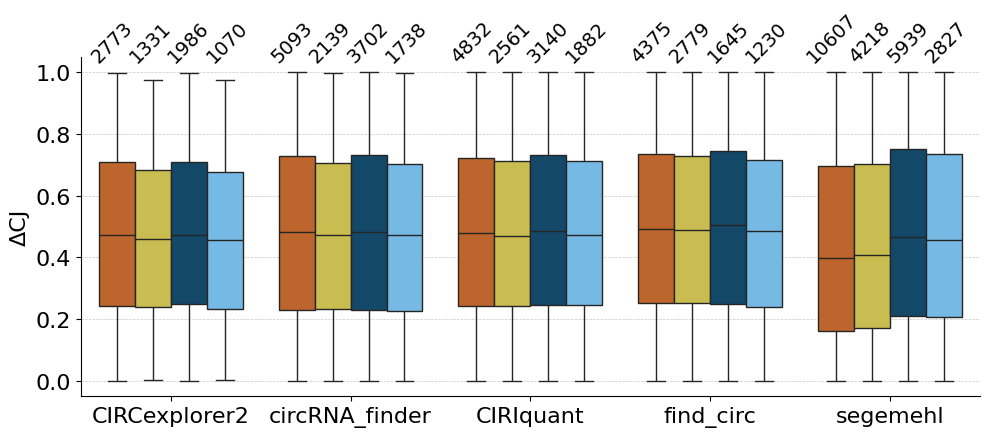

Kruskal-Wallis test for filtering method unfilter: H = 213.9685, p = 0.0000
  Dunn's test for unfilter: 
                CIRCexplorer2     CIRIquant  circRNA_finder     find_circ  \
CIRCexplorer2    1.000000e+00  1.000000e+00    1.000000e+00  1.929804e-01   
CIRIquant        1.000000e+00  1.000000e+00    1.000000e+00  1.000000e+00   
circRNA_finder   1.000000e+00  1.000000e+00    1.000000e+00  9.305318e-01   
find_circ        1.929804e-01  1.000000e+00    9.305318e-01  1.000000e+00   
segemehl         2.871254e-11  1.182327e-23    1.036620e-22  2.330673e-29   

                    segemehl  
CIRCexplorer2   2.871254e-11  
CIRIquant       1.182327e-23  
circRNA_finder  1.036620e-22  
find_circ       2.330673e-29  
segemehl        1.000000e+00  
Kruskal-Wallis test for filtering method filter-split: H = 59.7694, p = 0.0000
  Dunn's test for filter-split: 
                CIRCexplorer2  CIRIquant  circRNA_finder     find_circ  \
CIRCexplorer2        1.000000   1.000000        1.000000  1.

In [7]:
circRNA_matrix = "CJ/circRNA/real"
filtering_methods = ["unfilter", "filter-split", "filter-duplicates", "filter"]
data = 'CNT'
circRNA_tools = ["CIRCexplorer2", "circRNA_finder", "CIRIquant", "find_circ", "segemehl"]  

circle_diff_real(circRNA_matrix, circRNA_tools, filtering_methods, data)

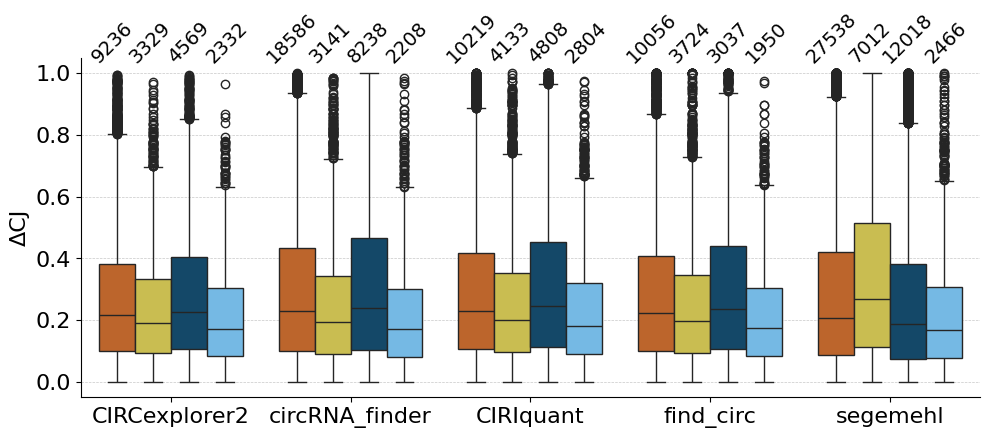

Kruskal-Wallis test for filtering method unfilter: H = 90.7652, p = 0.0000
  Dunn's test for unfilter: 
                CIRCexplorer2     CIRIquant  circRNA_finder  find_circ  \
CIRCexplorer2    1.000000e+00  5.700202e-06    2.152603e-09   0.008386   
CIRIquant        5.700202e-06  1.000000e+00    1.000000e+00   0.919853   
circRNA_finder   2.152603e-09  1.000000e+00    1.000000e+00   0.082376   
find_circ        8.385501e-03  9.198533e-01    8.237632e-02   1.000000   
segemehl         1.000000e+00  6.761282e-08    1.012399e-14   0.001904   

                    segemehl  
CIRCexplorer2   1.000000e+00  
CIRIquant       6.761282e-08  
circRNA_finder  1.012399e-14  
find_circ       1.904018e-03  
segemehl        1.000000e+00  
Kruskal-Wallis test for filtering method filter-split: H = 459.4664, p = 0.0000
  Dunn's test for filter-split: 
                CIRCexplorer2     CIRIquant  circRNA_finder     find_circ  \
CIRCexplorer2    1.000000e+00  8.106449e-02    1.000000e+00  3.727850e-01  

In [8]:
circRNA_matrix = "CJ/circRNA/real"
filtering_methods = ["unfilter", "filter-split", "filter-duplicates", "filter"]
data = 'RNASE'
circRNA_tools = ["CIRCexplorer2", "circRNA_finder", "CIRIquant", "find_circ", "segemehl"]  

circle_diff_real(circRNA_matrix, circRNA_tools, filtering_methods, data)

In [2]:
process_circle_matrix_mappability(
        "results/eccDNA/real/Circle-Seq/Circle-Seq.bed",
        "output/eccDNA/real/Circle-Seq/bwa/CS_sorted_unknown_circle.bam",
        "CJ/eccDNA/real/Circle-Seq/all_reads.csv",
        use_chr_prefix=False,
        N_offset=20, 
        verbose=False
    )

Skipping invalid chromosome: M or region M:32-8150. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:19-211. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:342-1130. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:394-2802. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:414-14902. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:455-16184. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:520-564. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:525-14363. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:777-904. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:995-5131. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:1010-4996. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:1243-3798. Error: invalid contig `M`
Skipping invalid chromosome: M or region M:1250-1572

In [3]:
process_circle_matrix_mappability(
        "results/eccDNA/real/ATAC-seq/ATAC-seq.bed",
        "output/eccDNA/real/ATAC-seq/bwa/AS_sorted_unknown_circle.bam",
        "CJ/eccDNA/real/ATAC-seq/all_reads.csv",
        use_chr_prefix=True,
        N_offset=20, 
        verbose=False
    )

Skipping invalid chromosome: chrMT or region MT:0-16299. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrMT or region MT:652-8747. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrMT or region MT:11467-11796. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrMT or region MT:0-16295. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrMT or region MT:2-16299. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrMT or region MT:3-16299. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrMT or region MT:4-16299. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrMT or region MT:5-16299. Error: invalid contig `chrMT`
Skipping invalid chromosome: chrM or region M:0-16299. Error: start out of range (-20)
Skipping invalid chromosome: chrUn_JH584304 or region Un_JH584304:15-114452. Error: start out of range (-5)


In [4]:
process_circle_matrix_mappability(
    "results/circRNA/real/CNT/CNT.bed",
    "output/circRNA/real/star/CNT.Aligned.sorted.out.bam",
    "CJ/circRNA/real/CNT/all_reads.csv",
    use_chr_prefix=True,
    N_offset=20, 
    verbose=False
)

Skipping invalid chromosome: chrM or region M:0-16569. Error: start out of range (-20)
Skipping invalid chromosome: chrUn_GL000216v2 or region Un_GL000216v2:12-5381. Error: start out of range (-8)
Skipping invalid chromosome: chrUn_KI270333v1 or region Un_KI270333v1:8-1522. Error: start out of range (-12)
Skipping invalid chromosome: chrUn_KI270333v1 or region Un_KI270333v1:9-133. Error: start out of range (-11)
Skipping invalid chromosome: chrUn_KI270333v1 or region Un_KI270333v1:12-943. Error: start out of range (-8)


In [5]:
process_circle_matrix_mappability(
    "results/circRNA/real/RNASE/RNASE.bed",
    "output/circRNA/real/star/RNASE.Aligned.sorted.out.bam",
    "CJ/circRNA/real/RNASE/all_reads.csv",
    use_chr_prefix=True,
    N_offset=20, 
    verbose=False
)

Skipping invalid chromosome: chrM or region M:0-16569. Error: start out of range (-20)


In [6]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation

def diff_cj_combinations(circle, method, ros_combinations_mapping, filtering_methods, combining_method, palette):
    """
    Analyze ΔCJ (difference in circular junction reads) across combinations and compare against 'rosette'.

    Parameters:
        circle: Type of circle (e.g., 'circDNA')
        method: Method name (e.g., 'ciriquant')
        ros_combinations_mapping: Mapping of sample keys to group metadata
        filtering_methods: List of filtering methods (e.g., ['bwa', 'minimap2'])
        combining_method: List of combination strategies (e.g., ['union', 'rosette'])
        palette: dict mapping filtering method → color
    """
    data = []
    differences_data = []
    rosette_diff_cj = {}
    output_dir = f"CJ/{circle}/real/{method}/"
    os.makedirs(output_dir, exist_ok=True)

    n_threshold = 9
    alpha = 0.05

    # === Collect data ===
    for file_key, other in ros_combinations_mapping.items():
        for filter_method in filtering_methods:
            for combination in combining_method:
                file_path = f"CJ/{circle}/real/{filter_method}/{method}/{combination}/{file_key}.bed"
                if not os.path.exists(file_path) or os.stat(file_path).st_size == 0:
                    print(f"File {file_path} does not exist or is empty.")
                    continue
                try:
                    # BED files are usually tab-separated
                    df = pd.read_csv(file_path, sep="\t")

                    if "n_weighted" in df.columns and "rel diff weighted" in df.columns:
                        filter_data_max = df[df["n_weighted"] >= n_threshold]
                        filter_data_min = df[df["n_weighted"] < n_threshold]

                        if df.empty:
                            continue

                        diff_CJ = filter_data_max["n_weighted"].mean()

                        # Save Rosette reference
                        if combination == "rosette":
                            rosette_diff_cj[(file_key, filter_method)] = diff_CJ

                        # Collect stats
                        data.append({
                            "Combination": combination,
                            "Filtering": filter_method,
                            "Percentage CJ Reads >= 9": len(filter_data_max) / len(df) if len(df) > 0 else np.nan,
                            "Median ΔCJ (>=9)": filter_data_max["rel diff weighted"].median(),
                            "Mean ΔCJ (>=9)": filter_data_max["rel diff weighted"].mean(),
                            "Median ΔCJ (<9)": filter_data_min["rel diff weighted"].median(),
                            "Mean ΔCJ (<9)": filter_data_min["rel diff weighted"].mean(),
                            "Ratio p diff CJ < alpha (>=9)": len(filter_data_max[filter_data_max["p diff CJ"] < alpha]) / len(filter_data_max) if len(filter_data_max) > 0 else np.nan,
                            "Ratio p diff CJ* < alpha (>=9)": len(filter_data_max[filter_data_max["p diff CJ*"] < alpha]) / len(filter_data_max) if len(filter_data_max) > 0 else np.nan,
                            "Ratio p diff CJ < alpha (<9)": len(filter_data_min[filter_data_min["p diff CJ"] < alpha]) / len(filter_data_min) if len(filter_data_min) > 0 else np.nan,
                            "Ratio p diff CJ* < alpha (<9)": len(filter_data_min[filter_data_min["p diff CJ*"] < alpha]) / len(filter_data_min) if len(filter_data_min) > 0 else np.nan,
                        })

                        # Differences vs Rosette
                        if combination != "rosette" and (file_key, filter_method) in rosette_diff_cj:
                            rosette_mean = rosette_diff_cj[(file_key, filter_method)]
                            diff_cj_difference = rosette_mean - diff_CJ
                            differences_data.append({
                                "Key": file_key,
                                "Combination": combination,
                                "Filtering": filter_method,
                                "ΔCJ Difference": diff_cj_difference,
                            })

                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
        
    # Convert to DataFrames
    data_df = pd.DataFrame(data)
    differences_df = pd.DataFrame(differences_data)

    # === PLOT 1: Overall Diff CJ ===
    plt.figure(figsize=(7, 4))
    ax = sns.stripplot(
        data=data_df,
        x="Combination",
        y="Mean ΔCJ (>=9)",
        hue="Filtering",
        jitter=True,
        dodge=True,
        palette=palette,
    )
    plt.xlabel("")
    plt.ylabel("ΔCJ", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    sns.despine()
    plt.legend([], frameon=False)
    plt.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

    # Median + MAD lines
    filters = list(palette.keys())
    for m_index, m in enumerate(combining_method):
        for f_index, f in enumerate(filters):
            df_sub = data_df[(data_df["Combination"] == m) & (data_df["Filtering"] == f)]
            if not df_sub.empty:
                median = np.median(df_sub["Mean ΔCJ (>=9)"].values)
                MAD = median_abs_deviation(df_sub["Mean ΔCJ (>=9)"].values)
                x_pos = m_index + (f_index - len(filters) / 2) * 0.2 + 0.1
                w = 0.07
                plt.plot([x_pos - w, x_pos + w], [median, median], color="#232323", zorder=10)
                plt.plot([x_pos, x_pos], [median - MAD, median + MAD], color="#bcbcbc", zorder=10)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/diffCJ_overall.png", dpi=300)
    plt.show()

    # === PLOT 2: Difference from Rosette ===
    plt.figure(figsize=(7, 4))
    df_all = differences_df[differences_df["Combination"].isin(["union", "intersect", "double", "unique"])]
    ax = sns.stripplot(
        data=df_all,
        x="Combination",
        y="ΔCJ Difference",
        hue="Filtering",
        jitter=True,
        dodge=True,
        palette=palette,
    )
    plt.xlabel("")
    plt.ylabel("ΔCJ$_{\\mathrm{Rosette}}$ − ΔCJ$_{\\mathrm{Group}}$", fontsize=16)
    plt.axhline(y=0, color="#bcbcbc", linewidth=2, linestyle="--")
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    sns.despine()
    plt.legend([], frameon=False)
    plt.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

    # Median + MAD lines
    for m_index, m in enumerate(combining_method):
        for f_index, f in enumerate(filters):
            df_sub = df_all[(df_all["Combination"] == m) & (df_all["Filtering"] == f)]
            if not df_sub.empty:
                median = np.median(df_sub["ΔCJ Difference"].values)
                MAD = median_abs_deviation(df_sub["ΔCJ Difference"].values)
                x_pos = m_index + (f_index - len(filters) / 2) * 0.2 + 0.1
                w = 0.07
                plt.plot([x_pos - w, x_pos + w], [median, median], color="#232323", zorder=10)
                plt.plot([x_pos, x_pos], [median - MAD, median + MAD], color="#bcbcbc", zorder=10)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/diffCJ_vs_rosette_all_filters.png", dpi=300)
    plt.show()
    
    # Save CSVs for further analysis
    data_df.to_csv(f"{output_dir}/diffCJ_stats.csv", index=False)
    differences_df.to_csv(f"{output_dir}/diffCJ_vs_rosette.csv", index=False)

    print("Second Table (Difference Between Rosette and Other Combinations):")
    display_cols = ["Key", "Filtering", "Combination", "ΔCJ Difference"]
    print(differences_df[display_cols].sort_values(by=["Key", "Filtering", "Combination"]))


In [8]:
# Define the file paths and filtering methods
ros_combinations_mapping = {
    "CE_CM_CF": "CE_CM_CE_CF_CM_CF",
    "CE_CM_EB": "CE_CM_CE_EB_CM_EB",
    "CE_CM_EM": "CE_CM_CE_EM_CM_EM",
    "CE_CF_EB": "CE_CF_CE_EB_CF_EB",
    "CE_CF_EM": "CE_CF_CE_EM_CF_EM",
    "CE_EB_EM": "CE_EB_CE_EM_EB_EM",
    "CM_CF_EB": "CM_CF_CM_EB_CF_EB",
    "CM_CF_EM": "CM_CF_CM_EM_CF_EM",
    "CM_EB_EM": "CM_EB_CM_EM_EB_EM",
    "CF_EB_EM": "CF_EB_CF_EM_EB_EM",
    "CE_CM_CF_EB": "CE_CM_CE_CF_CE_EB_CM_CF_CM_EM_CF_EB",
    "CE_CM_CF_EM": "CE_CM_CE_CF_CE_EM_CM_CF_CM_EM_CF_EM",
    "CE_CM_EB_EM": "CE_CM_CE_EB_CE_EM_CM_EB_CM_EM_EB_EM",
    "CE_CF_EB_EM": "CE_CF_CE_EB_CE_EM_CF_EB_CF_EM_EB_EM",
    "CM_CF_EB_EM": "CM_CF_CM_EB_CM_EM_CF_EB_CF_EM_EB_EM",
    "CE_CM_CF_EB_EM": "CE_CM_CE_CF_CE_EB_CE_EM_CM_CF_CM_EB_CM_EM_CF_EB_CF_EM_EB_EM"
}

combining_method = ['rosette', 'union', 'intersect', 'double', 'unique']
palette = {
        'unfilter': '#d46014',
        'filter-split': '#ddcd3d',
        'filter-duplicates': '#064b76ff',
        'filter': '#63bdf6ff'
    }
filtering_methods = ["unfilter", "filter-split", "filter-duplicates", "filter"]

# Call the function to plot the graph
diff_cj_combinations('eccDNA', 'Circle-Seq', ros_combinations_mapping, filtering_methods, combining_method, palette=palette)

ValueError: Could not interpret value `Combination` for `x`. An entry with this name does not appear in `data`.

<Figure size 700x400 with 0 Axes>

In [9]:
def plot_diffCJ_scatterplot(list_dfs):
    """
    Creates a multi-panel scatterplot showing Mean ΔCJ (≥) vs number of tools (n_tools) 
    across combinations and methods, using filtering strategies as hue.
    
    Parameters:
        list_dfs (list of pd.DataFrame): List of DataFrames, one per method.
    """

    # Add 'n_tools' column
    for df in list_dfs:
        if 'Key' in df.columns:
            df['n_tools'] = df['Key'].apply(lambda x: len(str(x).split('_')))

    list_methods = ["Circle-Seq", "ATAC-seq", "CNT", "RNASE"]
    combinations = ['intersect', 'rosette', 'double', 'union', 'unique']
    n_rows = len(combinations)
    n_cols = len(list_methods)

    palette = {
        'unfilter': '#d46014',
        'filter-split': '#ddcd3d',
        'filter-duplicates': '#064b76ff',
        'filter': '#63bdf6ff'
    }

    fig = plt.figure(figsize=(20, 8))
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, wspace=0.2, hspace=0.15)

    all_handles = []
    all_labels = []

    for c, method in enumerate(list_methods):
        df = list_dfs[c]

        for r, combination in enumerate(combinations):
            ax = fig.add_subplot(gs[r, c])
            subset = df[df['Combination'] == combination]

            if not all(col in subset.columns for col in ['Mean ΔCJ (≥)', 'n_tools', 'Filtering']):
                ax.text(0.5, 0.5, "Missing columns", ha='center', va='center', fontsize=12, color='red')
                ax.set_axis_off()
                continue

            sns.scatterplot(
                data=subset,
                x='Mean ΔCJ (≥)',
                y='n_tools',
                hue='Filtering',
                palette=palette,
                s=50,
                ax=ax
            )

            if r == 0:
                ax.set_title(method, fontsize=16)

            if c == 0:
                ax.set_ylabel(combination, fontsize=16, rotation=0, ha='right', va='center')
            else:
                ax.set_ylabel('')

            ax.set_yticks([3, 4, 5])
            ax.set_ylim([2.5, 5.5])
            ax.tick_params(axis='y', labelsize=16)

            if r == 4:
                ax.set_xlabel('Mean ΔCJ (≥)', fontsize=16)
                ax.tick_params(axis='x', labelsize=16)

                if not subset.empty:
                    x_min = subset['Mean ΔCJ (≥)'].min()
                    x_max = subset['Mean ΔCJ (≥)'].max()
                    xticks = np.linspace(x_min, x_max, num=4)
                    ax.set_xticks(xticks)
                    ax.set_xticklabels([f"{x:.2f}" for x in xticks])
            else:
                ax.set_xticks([])
                ax.set_xticklabels([])
                ax.set_xlabel('')

            ax.get_legend().remove()

            if not all_handles:
                all_handles, all_labels = ax.get_legend_handles_labels()

    fig.legend(all_handles, all_labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=False, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig("CJ/eccDNA/real/diffCJ_scatterplot.png", dpi=300, bbox_inches="tight")
    plt.show()


In [12]:
def diff_cj_combinations(circle, method, ros_combinations_mapping, filtering_methods, combining_method):
    """
    Analyze ΔCJ (difference in circular junction reads) across combinations and compare against 'rosette'.

    Parameters:
        circle: Type of circle (e.g., 'circDNA')
        method: Method name (e.g., 'ciriquant')
        ros_combinations_mapping: Mapping of sample keys to group metadata
        filtering_methods: List of filtering methods (e.g., ['bwa', 'minimap2'])
        combining_method: List of combination strategies (e.g., ['union', 'rosette'])
    """
    data = []
    differences_data = []
    rosette_diff_cj = {}
    output_dir = f"results/{circle}/real/{method}/"
    os.makedirs(output_dir, exist_ok=True)

    n_threshold = 9
    alpha = 0.05

    for file_key, other in ros_combinations_mapping.items():
        for filter_method in filtering_methods:
            for combination in combining_method:
                file_path = f"results/{circle}/real/{filter_method}/{method}/{combination}/{file_key}.bed"
                if not os.path.exists(file_path) or os.stat(file_path).st_size == 0:
                    print(f"File {file_path} does not exist or is empty.")
                    continue
                try:
                    df = pd.read_csv(file_path, sep=',')
                    if 'diff CJ' in df.columns and 'CJ Reads' in df.columns:
                        tool_data = df
                        filter_data_max = df[df['CJ Reads'] >= n_threshold]
                        filter_data_min = df[df['CJ Reads'] < n_threshold]

                        if df.empty:
                            continue

                        diff_CJ = filter_data_max['diff CJ'].mean()

                        if combination == "rosette":
                            rosette_diff_cj[(file_key, filter_method)] = diff_CJ
                        percent_max = len(filter_data_max) / len(tool_data) if len(tool_data) > 0 else np.nan
                        data.append({
                            'Combination': combination,
                            'Key': file_key,
                            'Filtering': filter_method,
                            'CJ ≥ threshold (%)': f"{percent_max:.2%}",
                            'CJ ≥ threshold (n)': len(filter_data_max),
                            'CJ < threshold (n)': len(filter_data_min),
                            'Median ΔCJ (≥)': filter_data_max['diff CJ'].median(),
                            'Mean ΔCJ (≥)': filter_data_max['diff CJ'].mean(),
                            'Median ΔCJ (<)': filter_data_min['diff CJ'].median(),
                            'Mean ΔCJ (<)': filter_data_min['diff CJ'].mean(),
                            f'Ratio p diff CJ < {alpha} (≥)': (filter_data_max['p diff CJ'] < alpha).mean(),
                            f'Count p diff CJ < {alpha} (≥)': (filter_data_max['p diff CJ'] < alpha).sum(),
                            f'Ratio p diff CJ < {alpha} (<)': (filter_data_min['p diff CJ'] < alpha).mean(),
                            f'Count p diff CJ < {alpha} (<)': (filter_data_min['p diff CJ'] < alpha).sum(),
                            f'Ratio p diff CJ* < {alpha} (≥)': (filter_data_max['p diff CJ*'] < alpha).mean(),
                            f'Count p diff CJ* < {alpha} (≥)': (filter_data_max['p diff CJ*'] < alpha).sum(),
                            f'Ratio p diff CJ* < {alpha} (<)': (filter_data_min['p diff CJ*'] < alpha).mean(),
                            f'Count p diff CJ* < {alpha} (<)': (filter_data_min['p diff CJ*'] < alpha).sum()
                        })

                        if combination != "rosette" and (file_key, filter_method) in rosette_diff_cj:
                            rosette_mean = rosette_diff_cj[(file_key, filter_method)]
                            diff_cj_difference = rosette_mean - diff_CJ
                            differences_data.append({
                                'Key': file_key,
                                'Combination': combination,
                                'Filtering': filter_method,
                                'ΔCJ Difference': diff_cj_difference
                            }) 

                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
                    
    # Convert data lists to DataFrames
    data_df = pd.DataFrame(data)

    differences_df = pd.DataFrame(differences_data)

    # === PLOT 1: Overall Diff CJ ===
    plt.figure(figsize=(7, 4))
    ax = sns.stripplot(data=data_df, x="Combination", y="Mean ΔCJ (≥)", hue="Filtering", jitter=True, dodge=True, palette=palette)
    plt.xlabel("")
    plt.ylabel("ΔCJ", fontsize=16)
    capitalize_xticks(ax)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    sns.despine()
    plt.legend([], frameon=False)
    plt.grid(axis="y", linestyle='--', linewidth=0.5, alpha=0.7)

    filters = list(palette.keys())
    for m_index, m in enumerate(combining_method):
        for f_index, f in enumerate(filters):
            x_pos = m_index + (f_index - len(filters) / 2) * 0.2 + 0.1
            df_sub = data_df[(data_df['Combination'] == m) & (data_df['Filtering'] == f)]
            if not df_sub.empty:
                median = np.median(df_sub["Mean ΔCJ (≥)"].values)
                MAD = median_abs_deviation(df_sub["Mean ΔCJ (≥)"].values)
                w = 0.07
                plt.plot([x_pos - w, x_pos + w], [median, median], color="#232323", zorder=10)
                plt.plot([x_pos + w, x_pos + w], [median + MAD, median - MAD], color="#bcbcbc", zorder=10)


    plt.tight_layout()
    plt.savefig(f"{output_dir}/diffCJ_overall.png", dpi=300)
    plt.show()

    # === PLOT 2: Difference from Rosette ===
    plt.figure(figsize=(7, 4))
    df_all = differences_df[differences_df['Combination'].isin(['union', 'intersect', 'double', 'unique'])]
    ax = sns.stripplot(data=df_all, x="Combination", y="ΔCJ Difference", hue="Filtering", jitter=True, dodge=True, palette=palette)
    plt.xlabel("")
    plt.ylabel("ΔCJ$_{\\mathrm{Rosette}}$ − ΔCJ$_{\\mathrm{Group}}$", fontsize=16)
    plt.axhline(y=0, color='#bcbcbc', linewidth=2,  linestyle='--')
    capitalize_xticks(ax)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    sns.despine()
    plt.legend([], frameon=False)
    plt.grid(axis="y", linestyle='--', linewidth=0.5, alpha=0.7)

    filters = list(palette.keys())
    for m_index, m in enumerate(combining_method):   
        for f_index, f in enumerate(filters):
            x_pos = m_index + (f_index - 2) * 0.2 + 0.1 -1
            df_sub = df_all[(df_all['Combination'] == m) & (df_all['Filtering'] == f)]
            if not df_sub.empty:
                median = np.median(df_sub["ΔCJ Difference"].values)
                MAD = median_abs_deviation(df_sub["ΔCJ Difference"].values)
                w = 0.07
                plt.plot([x_pos - w, x_pos + w], [median, median], color="#232323", zorder=10)
                plt.plot([x_pos + w, x_pos + w], [median + MAD, median - MAD], color="#bcbcbc", zorder=10)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/diffCJ_vs_rosette_all_filters.png", dpi=300)
    plt.show()
    
    # Save CSVs for further analysis
    data_df.to_csv(f"{output_dir}/diffCJ_stats.csv", index=False)
    differences_df.to_csv(f"{output_dir}/diffCJ_vs_rosette.csv", index=False)

    print("Second Table (Difference Between Rosette and Other Combinations):")
    display_cols = ['Key', 'Filtering', 'Combination', 'ΔCJ Difference']
    print(differences_df[display_cols].sort_values(by=["Key", "Filtering", "Combination"]))

In [16]:
def capitalize_xticks(ax):
    """Helper function to capitalize x-axis tick labels."""
    labels = [label.get_text().capitalize() for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels)
# Define the file paths and filtering methods
ros_combinations_mapping = {
    "CE_CM_CF": "CE_CM_CE_CF_CM_CF",
    "CE_CM_EB": "CE_CM_CE_EB_CM_EB",
    "CE_CM_EM": "CE_CM_CE_EM_CM_EM",
    "CE_CF_EB": "CE_CF_CE_EB_CF_EB",
    "CE_CF_EM": "CE_CF_CE_EM_CF_EM",
    "CE_EB_EM": "CE_EB_CE_EM_EB_EM",
    "CM_CF_EB": "CM_CF_CM_EB_CF_EB",
    "CM_CF_EM": "CM_CF_CM_EM_CF_EM",
    "CM_EB_EM": "CM_EB_CM_EM_EB_EM",
    "CF_EB_EM": "CF_EB_CF_EM_EB_EM",
    "CE_CM_CF_EB": "CE_CM_CE_CF_CE_EB_CM_CF_CM_EM_CF_EB",
    "CE_CM_CF_EM": "CE_CM_CE_CF_CE_EM_CM_CF_CM_EM_CF_EM",
    "CE_CM_EB_EM": "CE_CM_CE_EB_CE_EM_CM_EB_CM_EM_EB_EM",
    "CE_CF_EB_EM": "CE_CF_CE_EB_CE_EM_CF_EB_CF_EM_EB_EM",
    "CM_CF_EB_EM": "CM_CF_CM_EB_CM_EM_CF_EB_CF_EM_EB_EM",
    "CE_CM_CF_EB_EM": "CE_CM_CE_CF_CE_EB_CE_EM_CM_CF_CM_EB_CM_EM_CF_EB_CF_EM_EB_EM"
}

combining_method = ['rosette', 'union', 'intersect', 'double', 'unique']

/tmp/ipykernel_55819/3969985328.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


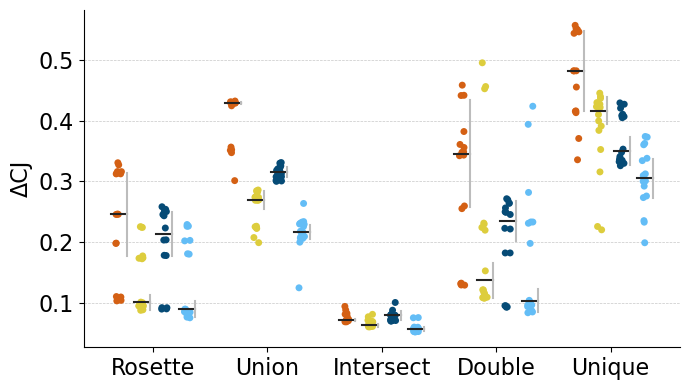

/tmp/ipykernel_55819/3969985328.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


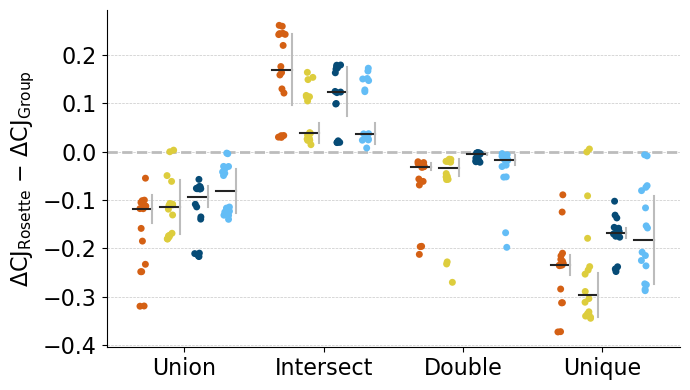

Second Table (Difference Between Rosette and Other Combinations):
          Key          Filtering Combination  ΔCJ Difference
62   CE_CF_EB             filter      double       -0.008514
61   CE_CF_EB             filter   intersect        0.023931
60   CE_CF_EB             filter       union       -0.140095
63   CE_CF_EB             filter      unique       -0.236177
58   CE_CF_EB  filter-duplicates      double       -0.017857
..        ...                ...         ...             ...
135  CM_EB_EM       filter-split      unique        0.005163
130  CM_EB_EM           unfilter      double       -0.212514
129  CM_EB_EM           unfilter   intersect        0.158077
128  CM_EB_EM           unfilter       union       -0.055127
131  CM_EB_EM           unfilter      unique       -0.089484

[256 rows x 4 columns]


In [17]:
# Call the function to plot the graph
diff_cj_combinations('eccDNA', 'Circle-Seq', ros_combinations_mapping, filtering_methods, combining_method)

/tmp/ipykernel_55819/3969985328.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


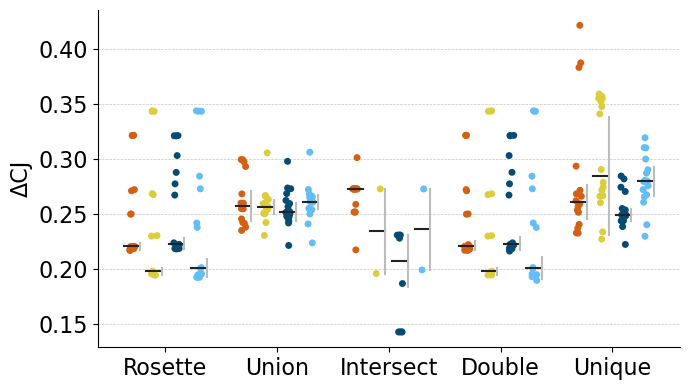

/tmp/ipykernel_55819/3969985328.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


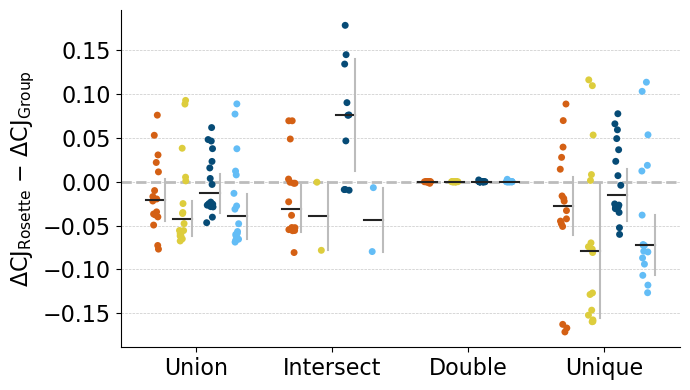

Second Table (Difference Between Rosette and Other Combinations):
          Key          Filtering Combination  ΔCJ Difference
56   CE_CF_EB             filter      double        0.000049
55   CE_CF_EB             filter   intersect       -0.079619
54   CE_CF_EB             filter       union       -0.056788
57   CE_CF_EB             filter      unique       -0.106726
52   CE_CF_EB  filter-duplicates      double        0.000010
..        ...                ...         ...             ...
120  CM_EB_EM       filter-split      unique        0.053279
116  CM_EB_EM           unfilter      double       -0.000042
115  CM_EB_EM           unfilter   intersect        0.048730
114  CM_EB_EM           unfilter       union        0.075929
117  CM_EB_EM           unfilter      unique        0.088633

[222 rows x 4 columns]


In [18]:
# Call the function to plot the graph
diff_cj_combinations('eccDNA', 'ATAC-seq', ros_combinations_mapping, filtering_methods, combining_method)

/tmp/ipykernel_55819/3969985328.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


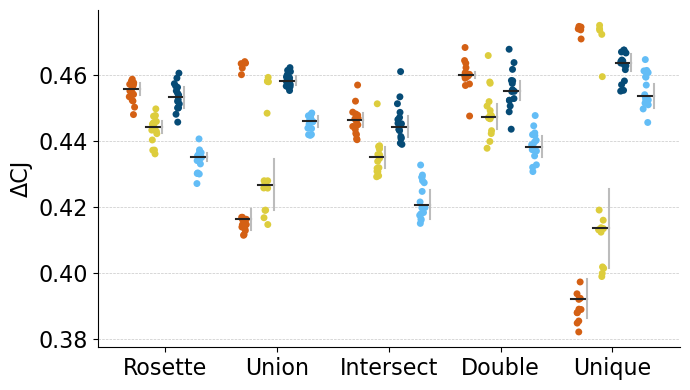

/tmp/ipykernel_55819/3969985328.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


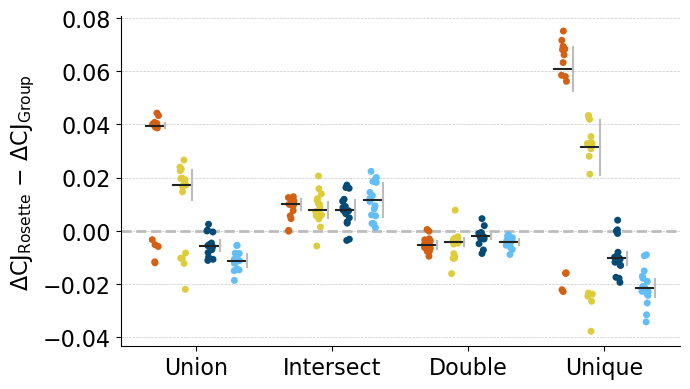

Second Table (Difference Between Rosette and Other Combinations):
          Key          Filtering Combination  ΔCJ Difference
14   CE_CF_CQ             filter      double       -0.002632
13   CE_CF_CQ             filter   intersect        0.001169
12   CE_CF_CQ             filter       union       -0.011842
15   CE_CF_CQ             filter      unique       -0.021932
10   CE_CF_CQ  filter-duplicates      double        0.004535
..        ...                ...         ...             ...
151  CQ_FC_SE       filter-split      unique        0.032093
146  CQ_FC_SE           unfilter      double       -0.000184
145  CQ_FC_SE           unfilter   intersect        0.000142
144  CQ_FC_SE           unfilter       union        0.044289
147  CQ_FC_SE           unfilter      unique        0.068154

[256 rows x 4 columns]


In [19]:
ros_combinations_mapping = {
    "CE_CF_CQ": "CE_CF_CE_CQ_CF_CQ",
    "CE_CF_FC": "CE_CF_CE_FC_CF_FC",
    "CE_CF_SE": "CE_CF_CE_SE_CF_SE",
    "CE_CQ_FC": "CE_CQ_CE_FC_CQ_FC",
    "CE_CQ_SE": "CE_CQ_CE_SE_CQ_SE",
    "CE_FC_SE": "CE_FC_CE_SE_FC_SE",
    "CF_CQ_FC": "CF_CQ_CF_FC_CQ_FC",
    "CF_CQ_SE": "CF_CQ_CF_SE_CQ_SE",
    "CF_FC_SE": "CF_FC_CF_SE_FC_SE",
    "CQ_FC_SE": "CQ_FC_CQ_SE_FC_SE",
    "CE_CF_CQ_FC": "CE_CF_CE_CQ_CE_FC_CF_CQ_CF_SE_CQ_FC",
    "CE_CF_CQ_SE": "CE_CF_CE_CQ_CE_SE_CF_CQ_CF_SE_CQ_SE",
    "CE_CF_FC_SE": "CE_CF_CE_FC_CE_SE_CF_FC_CF_SE_FC_SE",
    "CE_CQ_FC_SE": "CE_CQ_CE_FC_CE_SE_CQ_FC_CQ_SE_FC_SE",
    "CF_CQ_FC_SE": "CF_CQ_CF_FC_CF_SE_CQ_FC_CQ_SE_FC_SE",
    "CE_CF_CQ_FC_SE": "CE_CF_CE_CQ_CE_FC_CE_SE_CF_CQ_CF_FC_CF_SE_CQ_FC_CQ_SE_FC_SE"
}
diff_cj_combinations('circRNA', 'CNT', ros_combinations_mapping, filtering_methods, combining_method)

/tmp/ipykernel_55819/3969985328.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


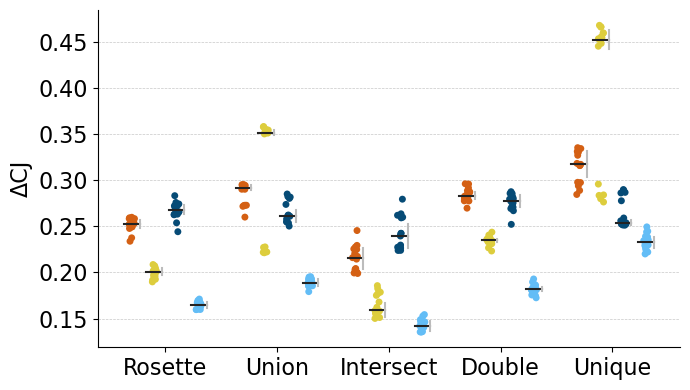

/tmp/ipykernel_55819/3969985328.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


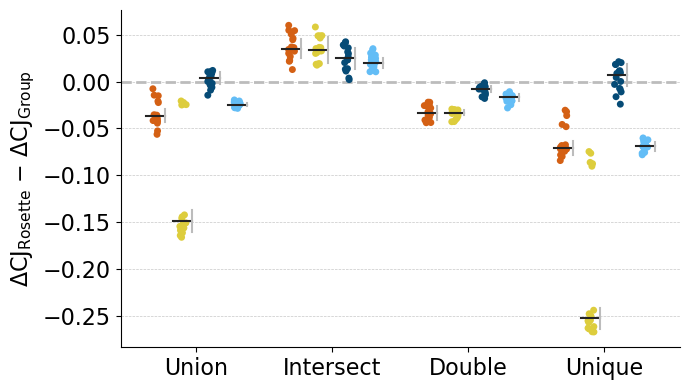

Second Table (Difference Between Rosette and Other Combinations):
          Key          Filtering Combination  ΔCJ Difference
14   CE_CF_CQ             filter      double       -0.020281
13   CE_CF_CQ             filter   intersect        0.010607
12   CE_CF_CQ             filter       union       -0.021908
15   CE_CF_CQ             filter      unique       -0.071017
10   CE_CF_CQ  filter-duplicates      double       -0.014362
..        ...                ...         ...             ...
151  CQ_FC_SE       filter-split      unique       -0.244133
146  CQ_FC_SE           unfilter      double       -0.041014
145  CQ_FC_SE           unfilter   intersect        0.030192
144  CQ_FC_SE           unfilter       union       -0.044362
147  CQ_FC_SE           unfilter      unique       -0.068227

[256 rows x 4 columns]


In [20]:
diff_cj_combinations('circRNA', 'RNASE', ros_combinations_mapping, filtering_methods, combining_method)

/tmp/ipykernel_55819/1738668312.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


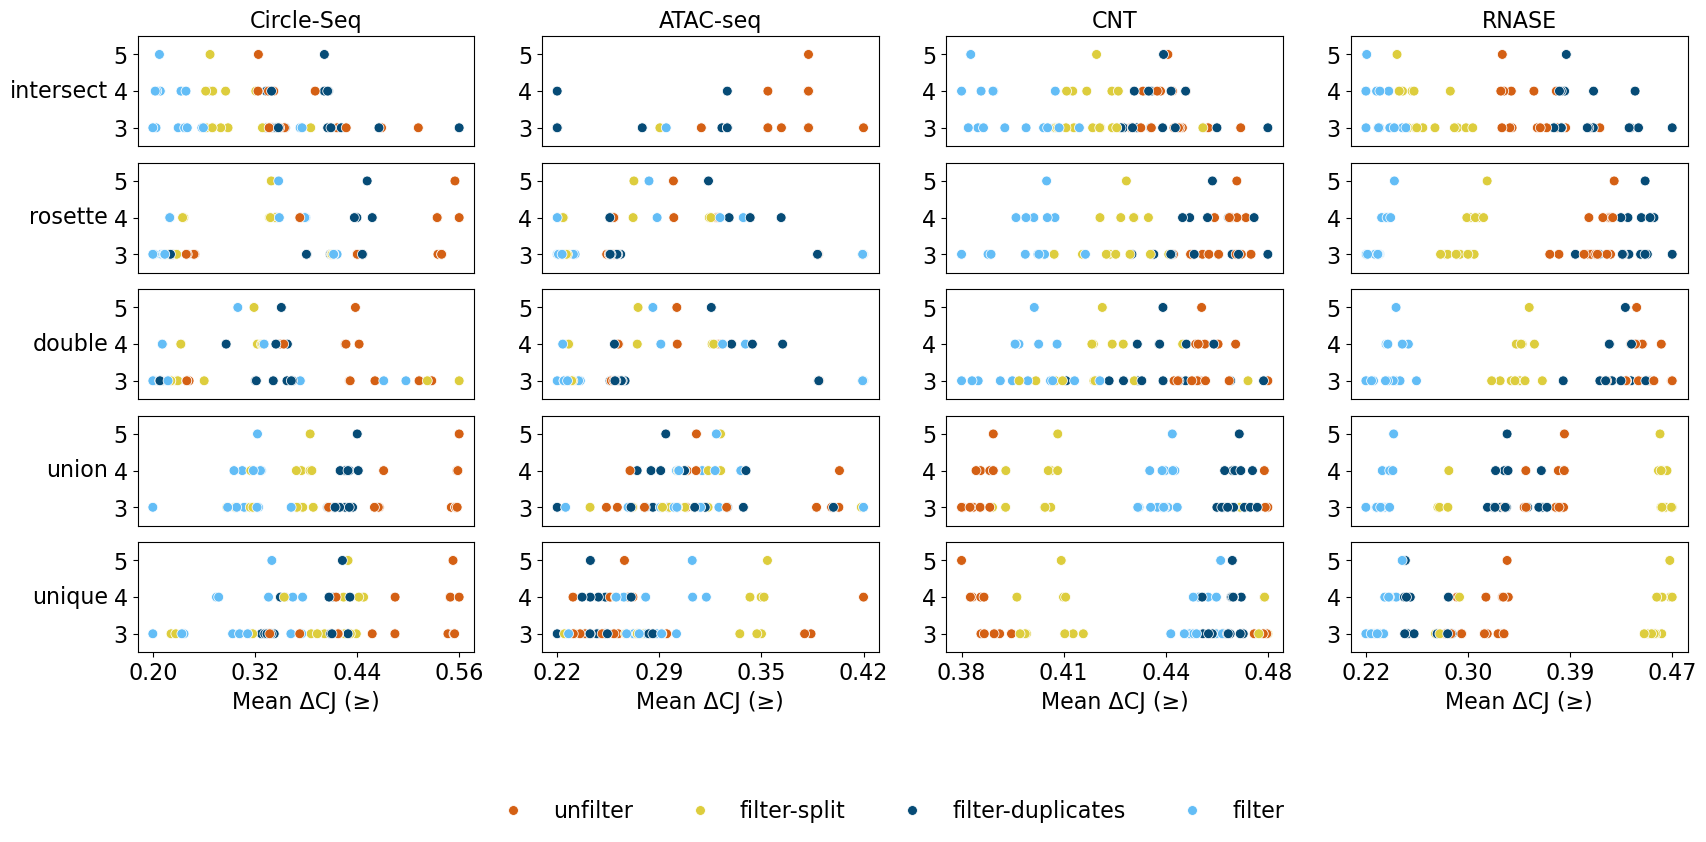

In [11]:
import os
import pandas as pd
import pysam
import pyBigWig
from scipy.stats import binom, kruskal, median_abs_deviation
from statsmodels.stats.multitest import multipletests as multi
from matplotlib import pyplot as plt
import seaborn as sns
import scikit_posthocs as sp
import numpy as np
import matplotlib.gridspec as gridspec
list_dfs = [
    pd.read_csv("results/eccDNA/real/Circle-Seq/diffCJ_stats.csv"),
    pd.read_csv("results/eccDNA/real/ATAC-seq/diffCJ_stats.csv"),
    pd.read_csv("results/circRNA/real/CNT/diffCJ_stats.csv"),
    pd.read_csv("results/circRNA/real/RNASE/diffCJ_stats.csv")
]

plot_diffCJ_scatterplot(list_dfs)